# Gaussian Measures on Function Spaces

This notebook illustrates how to work with **Gaussian measures defined on a function space** — specifically, the space of square-integrable functions on the 2-sphere $\mathbb{S}^2$ — and how to compare credible sets both in the function space itself and in a **finite-dimensional observation space**.

### Key ideas

1. **Prior measure on a function space.** We define a Gaussian measure $\mu_0 = \mathcal{N}(0, C)$ on $L^2(\mathbb{S}^2)$, where the covariance operator $C = e^{-\sigma^2\Delta}$ is an isotropic heat-kernel operator.

2. **Credible set in the function space.** The 90% Mahalanobis credible set $E_{0.9}^{L^2} = \{u : \langle C^{-1}u, u\rangle \le r_{169}^2\}$ is a genuine subset of $L^2(\mathbb{S}^2)$. It cannot be plotted, but `pygeoinf` creates it as an `Ellipsoid` and `is_element(u)` evaluates membership for any function $u$.

3. **Observation operator via spherical cap averages.** We assemble two cap-average linear functionals into a property mapping $G : L^2(\mathbb{S}^2) \to \mathbb{R}^2$.

4. **Push-forward to $\mathbb{R}^2$.** `GaussianMeasure.affine_mapping(operator=G)` pushes the function-space Gaussian forward to $\mathcal{N}(0, GCG^*)$ on $\mathbb{R}^2$.

5. **Two ellipses in $\mathbb{R}^2$.** The *image* $G(E_{0.9}^{L^2})$ and the *push-forward credible set* $E_{0.9}^{\mathbb{R}^2}$ have the same shape but very different sizes (radii 13.89 vs 2.15).  The image is far larger because $G$ has a 167-dimensional null space: a function-space outlier is almost always extreme in a direction $G$ cannot see, so its cap averages look completely normal.

6. **Monte Carlo verification.** All 500 prior samples, including FS outliers, land inside the large image ellipse, confirming that function-space extremity is invisible to cap averages alone.

## Section 1 — Imports

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs

import pygeoinf as inf
import pygeoinf.symmetric_space.sphere as sph

np.random.seed(42)

## Section 2 — Function Space and Prior Measure

We work on the unit sphere $\mathbb{S}^2$ with a spectral truncation at degree $l_{\max} = 12$.  The function space is $L^2(\mathbb{S}^2)$ approximated by the first $(l_{\max}+1)^2 = 169$ real spherical-harmonic coefficients.

The prior covariance is the heat-kernel operator
$$
  C = e^{-\sigma^2 \Delta},
$$
where $\Delta$ is the (negative) Laplace–Beltrami operator on $\mathbb{S}^2$ and $\sigma$ controls the smoothness scale.  Functions drawn from this prior are smooth on angular scales larger than $\sigma$ radians.

In [14]:
# ── Function space ──────────────────────────────────────────────────────────
lmax = 12          # spectral truncation degree
L = sph.Lebesgue(lmax)
print(f"Function space: L²(S²),  dim = {L.dim}  (lmax = {L.lmax})")

# ── Heat-kernel prior ───────────────────────────────────────────────────────
sigma = 0.4        # smoothness scale (radians on unit sphere)
prior = L.heat_kernel_gaussian_measure(sigma)
print(f"Prior: N(0, exp(-{sigma}² Δ)),  domain dim = {prior.domain.dim}")

Function space: L²(S²),  dim = 169  (lmax = 12)
Prior: N(0, exp(-0.4² Δ)),  domain dim = 169


### Prior Samples on the Sphere

Before moving to the observation operator, it is instructive to see what functions drawn from $\mathcal{N}(0, C)$ look like on $\mathbb{S}^2$.  Each panel below shows one independent draw $u^{(k)} \sim \mathcal{N}(0, e^{-\sigma^2\Delta})$.  The heat-kernel covariance ensures the samples are spatially smooth at scales larger than $\sigma$ radians.

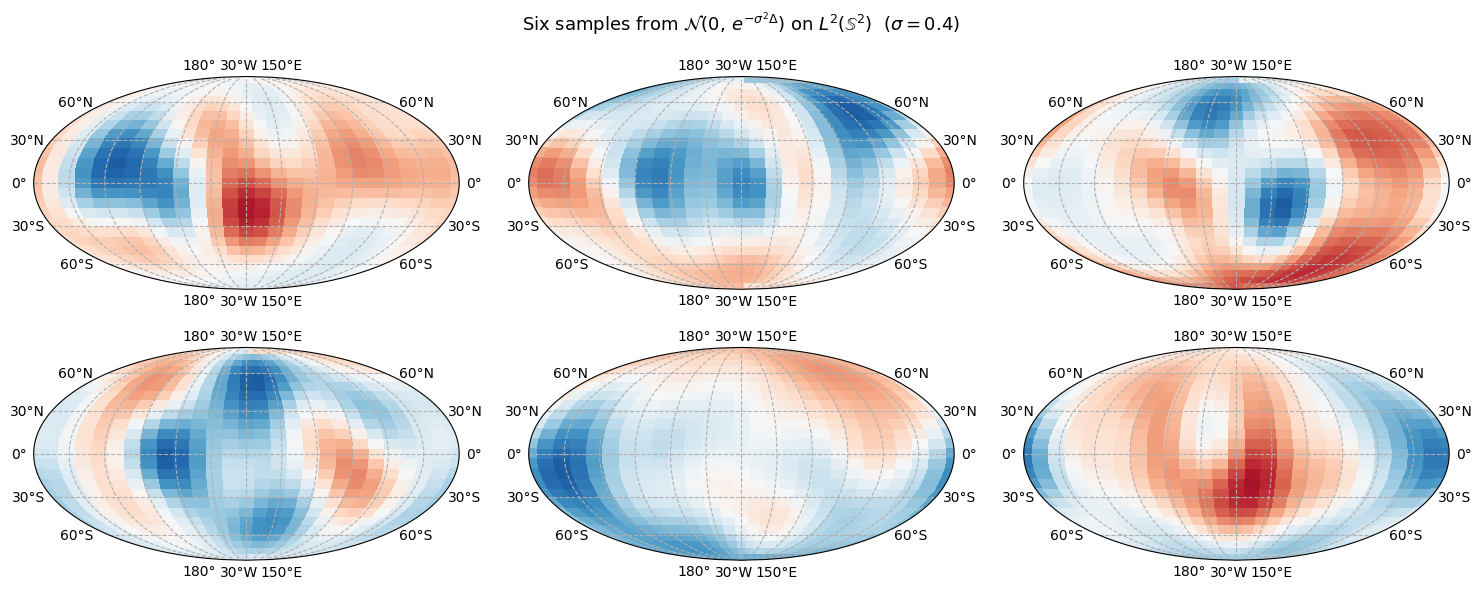

In [15]:
n_prior_samples = 6
proj = ccrs.Mollweide()
fig, axes = plt.subplots(
    2, 3, figsize=(15, 6),
    subplot_kw=dict(projection=proj),
)

for ax in axes.flat:
    u = prior.sample()
    sph.plot(u, ax=ax, cmap="RdBu_r", symmetric=True, gridlines=True)

fig.suptitle(
    f"Six samples from $\\mathcal{{N}}(0,\\, e^{{-\\sigma^2\\Delta}})$ on "
    f"$L^2(\\mathbb{{S}}^2)$  ($\\sigma = {sigma}$)",
    fontsize=13,
)
plt.tight_layout()
plt.show()

## Section 3 — Credible Set in the Function Space

Even though the function-space prior $\mu_0 = \mathcal{N}(0, C)$ lives in a 169-dimensional truncated $L^2(\mathbb{S}^2)$, we can form its **Mahalanobis credible ellipsoid** directly:

$$
  E_{0.9}^{L^2} = \bigl\{ u \in L^2(\mathbb{S}^2) : \langle C^{-1} u,\, u \rangle \le r_{0.9}^2 \bigr\},
$$

where $C^{-1} = e^{+\sigma^2 \Delta}$ is the precision operator and $r_{0.9} = \sqrt{F^{-1}_{\chi^2_{169}}(0.9)}$ is calibrated to the chi-squared distribution with $169 = (l_{\max}+1)^2$ degrees of freedom.

This set **cannot be plotted** (it lives in 169 dimensions), but:
- `pygeoinf` can create it as an `Ellipsoid` object, and
- `Ellipsoid.is_element(u)` checks $\langle C^{-1}u, u\rangle \le r^2$ for any function $u$.

We verify below that roughly 90% of samples from the prior fall inside the set.

Credible set type:      Ellipsoid
Domain:                 L²(S²),  dim = 169
Chi-square radius:      13.8906   (df = 169)

Single sample is_element: True

Empirical coverage (function space): 89.6%  (448/500)  — nominal 90%


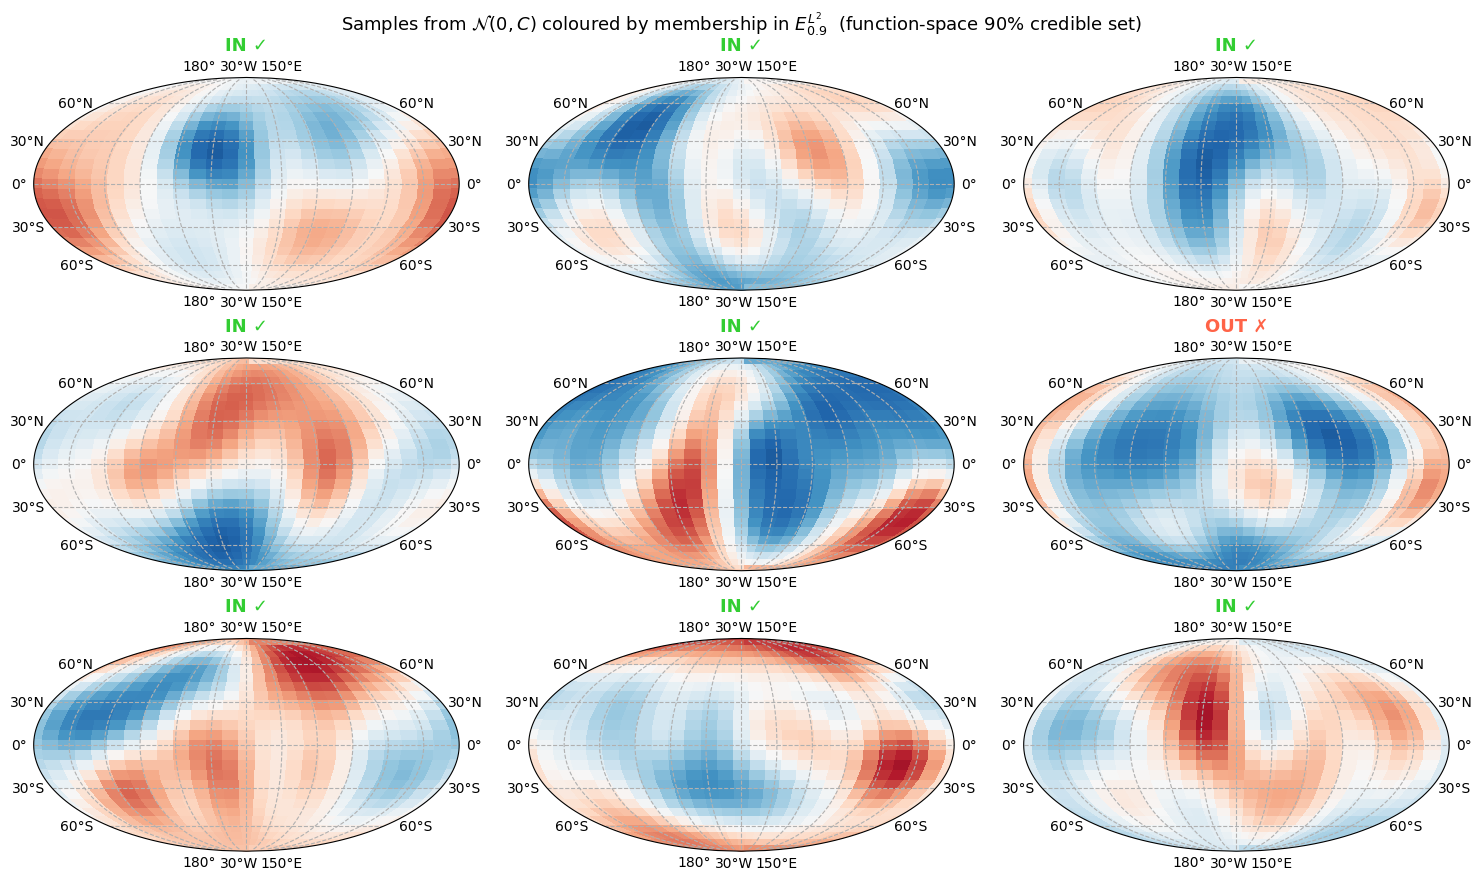

In [16]:
# ── Function-space credible set ─────────────────────────────────────────────
# InvariantGaussianMeasure already has inverse_covariance = C^{-1} = exp(+σ²Δ),
# so credible_set() works directly on the Lebesgue space.
prior_cred_set = prior.credible_set(0.90, geometry='ellipsoid')

print(f"Credible set type:      {type(prior_cred_set).__name__}")
print(f"Domain:                 L²(S²),  dim = {prior_cred_set.domain.dim}")
print(f"Chi-square radius:      {prior_cred_set.radius:.4f}   (df = {prior.domain.dim})")

# ── Membership test on a single sample ──────────────────────────────────────
u_test = prior.sample()
print(f"\nSingle sample is_element: {prior_cred_set.is_element(u_test)}")

# ── Empirical coverage ───────────────────────────────────────────────────────
n_check = 500
n_in_fs = sum(prior_cred_set.is_element(prior.sample()) for _ in range(n_check))
emp_fs  = n_in_fs / n_check
print(f"\nEmpirical coverage (function space): {emp_fs:.1%}  "
      f"({n_in_fs}/{n_check})  — nominal 90%")

# ── Visualise: colour 9 samples by inside / outside the credible set ─────────
proj = ccrs.Mollweide()
fig, axes = plt.subplots(3, 3, figsize=(15, 9),
                         subplot_kw=dict(projection=proj))

for ax in axes.flat:
    u = prior.sample()
    inside = prior_cred_set.is_element(u)
    sph.plot(u, ax=ax, cmap="RdBu_r", symmetric=True, gridlines=True)
    color  = "limegreen" if inside else "tomato"
    label  = "IN ✓"       if inside else "OUT ✗"
    ax.set_title(label, fontsize=13, color=color, fontweight='bold')

fig.suptitle(
    "Samples from $\\mathcal{N}(0,C)$ coloured by membership in "
    "$E_{0.9}^{L^2}$  (function-space 90% credible set)",
    fontsize=13,
)
plt.tight_layout()
plt.show()

## Section 4 — Spherical Cap Observation Kernels

We define two linear functionals by integrating a function $u$ against the normalised indicator of a spherical cap:
$$
  g_i(u) = \frac{1}{|C_i|} \int_{C_i} u(\mathbf{x})\, dS(\mathbf{x}),
  \qquad i = 1, 2,
$$
where $|C_i|$ is the area of cap $C_i$.  These are the *cap-average* linear forms.

The two caps are placed at antipodal locations on the sphere to make their averages as *decorrelated* as possible under the isotropic prior.

In [17]:
cap_radius = np.radians(35.0)   # angular radius of each cap

# Cap 1: centred at (lat = +45°, lon = 0°)
cap1_center = (45.0, 0.0)
cap1_form   = L.spherical_cap_average(cap1_center, cap_radius)

# Cap 2: centred at (lat = -45°, lon = 180°) — roughly antipodal to cap 1
cap2_center = (-45.0, 180.0)
cap2_form   = L.spherical_cap_average(cap2_center, cap_radius)

print(f"Cap 1: centre (lat={cap1_center[0]}°, lon={cap1_center[1]}°), radius={np.degrees(cap_radius):.1f}°")
print(f"Cap 2: centre (lat={cap2_center[0]}°, lon={cap2_center[1]}°), radius={np.degrees(cap_radius):.1f}°")

Cap 1: centre (lat=45.0°, lon=0.0°), radius=35.0°
Cap 2: centre (lat=-45.0°, lon=180.0°), radius=35.0°


### Visualising the target kernels on the sphere

The kernel of the cap-average functional is the normalised cap indicator $|C_i|^{-1} \mathbf{1}_{C_i}$.  We project these kernels onto the spectral basis and plot them on a global map using Cartopy.

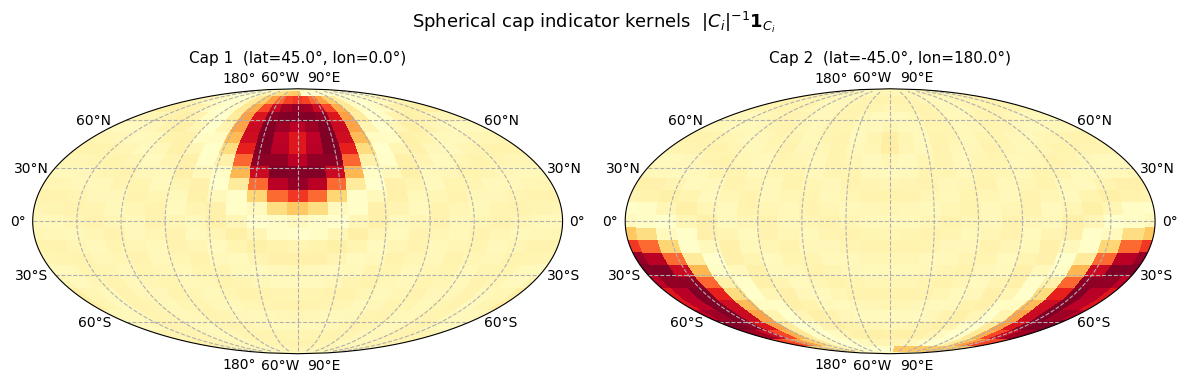

In [18]:
# Recover the spatial kernel (Riesz representative of cap_form in L²(S²))
kernel1_grid = L.from_dual(cap1_form)   # DHRealGrid object
kernel2_grid = L.from_dual(cap2_form)

proj = ccrs.Mollweide()
fig, axes = plt.subplots(
    1, 2, figsize=(12, 4),
    subplot_kw=dict(projection=proj)
)

for ax, kernel, center, label in zip(
    axes,
    [kernel1_grid, kernel2_grid],
    [cap1_center, cap2_center],
    ["Cap 1", "Cap 2"],
):
    sph.plot(kernel, ax=ax, cmap="YlOrRd", symmetric=False, gridlines=True)
    ax.set_title(f"{label}  (lat={center[0]}°, lon={center[1]}°)", fontsize=11)

fig.suptitle("Spherical cap indicator kernels  $|C_i|^{-1}\\mathbf{1}_{C_i}$", fontsize=13)
plt.tight_layout()
plt.show()

## Section 5 — Property Mapping and Push-Forward Measure

The two linear forms are stacked into a single operator
$$
  G : L^2(\mathbb{S}^2) \to \mathbb{R}^2,
  \quad u \mapsto \begin{pmatrix} g_1(u) \\ g_2(u) \end{pmatrix}.
$$

If $u \sim \mathcal{N}(0, C)$, then $G u \sim \mathcal{N}(0, G C G^*)$ where the push-forward covariance is the $2 \times 2$ matrix
$$
  \Sigma = G C G^* =
  \begin{pmatrix}
    \langle C g_1, g_1 \rangle & \langle C g_1, g_2 \rangle \\
    \langle C g_2, g_1 \rangle & \langle C g_2, g_2 \rangle
  \end{pmatrix}.
$$
Because the prior is isotropic and the caps are at antipodal positions, the off-diagonal terms are very small.

In [19]:
# ── Assemble observation operator ────────────────────────────────────────────
G = inf.LinearOperator.from_linear_forms([cap1_form, cap2_form])
print(f"G : dim {G.domain.dim}  →  dim {G.codomain.dim}")

# ── Push-forward via affine_mapping (pygeoinf native) ────────────────────────
# prior.affine_mapping(operator=G) computes the GaussianMeasure N(0, G C G*)
# and attaches a sample() method that maps prior samples through G automatically.
obs_measure_pf = prior.affine_mapping(operator=G)

# ── Extract the 2×2 covariance matrix and its inverse ────────────────────────
# The covariance is a LinearOperator on R²; .matrix(dense=True) gives the array.
Sigma     = obs_measure_pf.covariance.matrix(dense=True)
Sigma_inv = np.linalg.inv(Sigma)

print(f"\nPush-forward covariance  Σ = G C G* :")
print(Sigma)
print(f"\nCorrelation coefficient: {Sigma[0,1] / np.sqrt(Sigma[0,0]*Sigma[1,1]):.4f}")

# ── Augment with inverse covariance for credible_set() ───────────────────────
# credible_set(geometry='ellipsoid') requires an inverse covariance; for a 2×2
# dense matrix this is trivial. We reuse the push-forward sampler from above.
data_space  = inf.EuclideanSpace(2)
obs_measure = inf.GaussianMeasure(
    covariance=inf.LinearOperator.from_matrix(data_space, data_space, Sigma),
    inverse_covariance=inf.LinearOperator.from_matrix(data_space, data_space, Sigma_inv),
    sample=obs_measure_pf.sample,   # push-forward sampler: G(prior.sample())
)
print(f"\nPush-forward measure:  N(0, Σ)  on R²")

G : dim 169  →  dim 2

Push-forward covariance  Σ = G C G* :
[[3.34020540e-01 1.21984339e-04]
 [1.21984339e-04 3.34020540e-01]]

Correlation coefficient: 0.0004

Push-forward measure:  N(0, Σ)  on R²


## Section 6 — Credible Set in the Observation Space

The 90% credible set of the push-forward measure $\mathcal{N}(0, \Sigma)$ is a Mahalanobis ellipsoid in $\mathbb{R}^2$:
$$
  E_{0.9}^{\mathbb{R}^2} = \bigl\{ \mathbf{y} \in \mathbb{R}^2 : \mathbf{y}^\top \Sigma^{-1} \mathbf{y} \le r_{0.9}^2 \bigr\},
$$
where $r_{0.9} = \sqrt{F^{-1}_{\chi^2_2}(0.9)}$ is the radius calibrated to the chi-squared distribution with **2** degrees of freedom (note: smaller radius than the 169-dof function-space set).

`pygeoinf` renders this ellipsoid *exactly* — without any grid sampling — via the quadratic pullback algorithm.

In [20]:
credible_prob = 0.90

cred_set = obs_measure.credible_set(credible_prob, geometry='ellipsoid')
print(f"Credible set type:   {type(cred_set).__name__}")
print(f"Center:              {cred_set.center}")
print(f"Chi-square radius:   {cred_set.radius:.4f}")

Credible set type:   Ellipsoid
Center:              [0. 0.]
Chi-square radius:   2.1460


## Section 7 — Monte Carlo Samples: Function Space and $\mathbb{R}^2$

We draw 500 samples $u^{(k)} \sim \mathcal{N}(0, C)$ and for each one:
- check whether $u^{(k)} \in E_{0.9}^{L^2}$ (function-space membership via `prior_cred_set.is_element`), and
- compute $\mathbf{y}^{(k)} = G u^{(k)} \in \mathbb{R}^2$ (via `obs_measure.sample()`).

Both checks should give ~90% empirical coverage, but they are calibrated to *different* chi-squared distributions (169 vs 2 degrees of freedom).  The function-space check uses the full 169-dimensional precision operator; the 2D check uses only the projected covariance.

In [21]:
n_samples = 500

# Draw function-space samples and record:
#   - membership in the function-space credible set
#   - 2D image under G (via the push-forward sampler)
fs_samples   = [prior.sample() for _ in range(n_samples)]
fs_inside    = np.array([prior_cred_set.is_element(u) for u in fs_samples])
obs_samples  = np.array([G(u) for u in fs_samples])  # shape (n_samples, 2)

print(f"Function-space coverage: {fs_inside.mean():.1%}  "
      f"({fs_inside.sum()}/{n_samples})  — nominal 90%")
print(f"\nObs-space sample array shape: {obs_samples.shape}")
print(f"Sample mean:  {obs_samples.mean(axis=0)}")
print(f"Sample std:   {obs_samples.std(axis=0)}")
print(f"Analytic std: {np.sqrt(np.diag(Sigma))}")

Function-space coverage: 90.8%  (454/500)  — nominal 90%

Obs-space sample array shape: (500, 2)
Sample mean:  [ 0.01549254 -0.04117786]
Sample std:   [0.56366035 0.59089287]
Analytic std: [0.5779451 0.5779451]


## Section 8 — Sampling vs Membership: A Key Asymmetry

### Sampling commutes with $G$ — membership does not

For **measures**, sampling and mapping through $G$ commute perfectly:

$$u \sim \mu \;\Longrightarrow\; Gu \sim G_\# \mu.$$

Draw a sample from the function-space prior, apply $G$, and you get a sample from the push-forward measure. This works regardless of whether $G$ is injective — it is the very definition of push-forward.

For **credible sets**, the analogous statement fails. One might hope:

$$u \in E_{0.9}^{L^2} \;\Longleftrightarrow\; Gu \in E_{0.9}^{\mathbb{R}^2} \quad \text{(WRONG)}$$

It fails in both directions when $G$ is not injective:

| Direction | True? | Why |
|-----------|-------|-----|
| $u \in E_{0.9}^{L^2} \Rightarrow Gu \in G(E_{0.9}^{L^2})$ | ✓ always | Definition of image |
| $u \notin E_{0.9}^{L^2} \Rightarrow Gu \notin G(E_{0.9}^{L^2})$ | ✗ | $u$ may be extreme only in $\ker G$ |
| $Gu \in E_{0.9}^{\mathbb{R}^2} \Rightarrow u \in E_{0.9}^{L^2}$ | ✗ | $E_{0.9}^{\mathbb{R}^2} \neq G(E_{0.9}^{L^2})$ — different radii |
| $Gu \notin E_{0.9}^{\mathbb{R}^2} \Rightarrow u \notin E_{0.9}^{L^2}$ | ✓ contrapositive of first row (using $G(E_{0.9}^{L^2}) \supset E_{0.9}^{\mathbb{R}^2}$) | |

The root cause: $E_{0.9}^{\mathbb{R}^2}$ is **not** $G(E_{0.9}^{L^2})$. The 2D credible set is calibrated to 2 degrees of freedom (radius $r_2 \approx 2.15$); the image of the FS set uses the same quadratic form but calibrated to 169 dof (radius $r_{169} \approx 13.89$). They are geometrically similar ellipses but the image is 6.5× larger.

The preimage of the 2D credible set is
$$G^{-1}(E_{0.9}^{\mathbb{R}^2}) = \bigl\{u : Gu \in E_{0.9}^{\mathbb{R}^2}\bigr\},$$
which is an infinite-dimensional *cylinder* — all functions whose cap averages happen to be small, regardless of what they do in the null space. This cylinder intersects $E_{0.9}^{L^2}$ but also contains enormous functions that are extreme in directions $G$ cannot see.

> **Summary:** Push-forward of a *measure* is well-behaved under non-injective maps. Push-forward of a *credible set* is not — the 2D credible set of $G_\# \mu$ is not the image of the FS credible set under $G$.

### The two image ellipses

The linear map $G$ sends $E_{0.9}^{L^2}$ to:
$$
G\!\left(E_{0.9}^{L^2}\right)
= \bigl\{ y \in \mathbb{R}^2 : \langle \Sigma^{-1} y,\, y \rangle \le r_{169}^2 \bigr\}.
$$
The plot below shows both ellipses. Every sample, including FS outliers (red), lands inside the large orange image ellipse — their extremity is entirely in $\ker G$, invisible to cap averages.

Image ellipse radius (169 dof): 13.8906
2D credible ellipse radius (2 dof): 2.1460  (ratio 6.5×)

Samples inside G(E_fs) [large]:  500/500  (expect ALL)
Samples inside 2D ellipse [small]: 451/500  (expect ~90%)
FS outliers inside large ellipse:  46/46  (expect ALL)


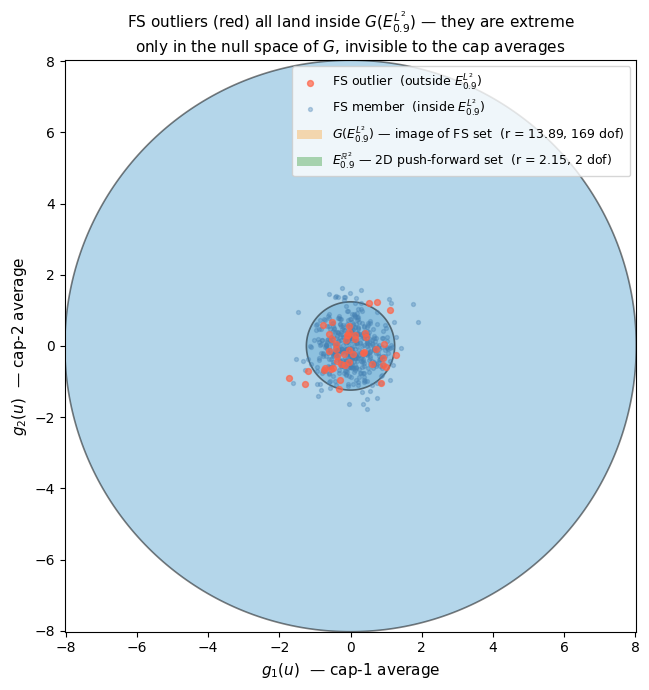


Key: ALL 46 FS outliers inside large image ellipse → their extremity is in ker(G), not in cap averages


In [22]:
from scipy.stats import chi2 as chi2_dist

# ── Radii ────────────────────────────────────────────────────────────────────
r_fs = prior_cred_set.radius                          # chi2(169) → ≈ 13.89
r_2d = float(np.sqrt(chi2_dist.ppf(0.90, df=2)))     # chi2(2)   → ≈ 2.15
print(f"Image ellipse radius (169 dof): {r_fs:.4f}")
print(f"2D credible ellipse radius (2 dof): {r_2d:.4f}  (ratio {r_fs/r_2d:.1f}×)")

# ── Mahalanobis distance for each sample ─────────────────────────────────────
centred    = obs_samples - cred_set.center
mahal_sq   = np.einsum('ni,ij,nj->n', centred, Sigma_inv, centred)
img_inside = mahal_sq <= r_fs**2      # inside G(E_fs): should be ALL
cred_inside = mahal_sq <= r_2d**2     # inside 2D credible set: ~90%

print(f"\nSamples inside G(E_fs) [large]:  {img_inside.sum()}/{n_samples}  (expect ALL)")
print(f"Samples inside 2D ellipse [small]: {cred_inside.sum()}/{n_samples}  (expect ~90%)")
print(f"FS outliers inside large ellipse:  {(~fs_inside & img_inside).sum()}/{(~fs_inside).sum()}  (expect ALL)")

# ── Plot ──────────────────────────────────────────────────────────────────────
std_vals = obs_samples.std(axis=0)
margin   = max(r_fs * np.sqrt(Sigma[0, 0]), 4.0 * std_vals[0])
bounds   = [(-margin, margin), (-margin, margin)]

fig, ax = plt.subplots(figsize=(7, 7))

# Large ellipse: image of the function-space credible set  (radius r_fs)
image_set = inf.GaussianMeasure(
    covariance=inf.LinearOperator.from_matrix(data_space, data_space, Sigma),
    inverse_covariance=inf.LinearOperator.from_matrix(data_space, data_space, Sigma_inv),
).credible_set(0.90, rank=prior.domain.dim)   # use 169 dof for radius

_, _, _ = image_set.plot(bounds=bounds, color="darkorange", show_plot=False, ax=ax)

# Small ellipse: 2D push-forward credible set  (radius r_2d)
_, _, _ = cred_set.plot(bounds=bounds, color="green", show_plot=False, ax=ax)

# Scatter: colour by FS inside / outside
ax.scatter(
    obs_samples[~fs_inside, 0], obs_samples[~fs_inside, 1],
    s=18, c="tomato", alpha=0.7, zorder=4, label="FS outlier  (outside $E_{0.9}^{L^2}$)",
)
ax.scatter(
    obs_samples[fs_inside, 0], obs_samples[fs_inside, 1],
    s=8, c="steelblue", alpha=0.35, zorder=3, label="FS member  (inside $E_{0.9}^{L^2}$)",
)

# Legend
orange_patch = mpatches.Patch(facecolor="darkorange", alpha=0.3,
    label=f"$G(E_{{0.9}}^{{L^2}})$ — image of FS set  (r = {r_fs:.2f}, 169 dof)")
green_patch  = mpatches.Patch(facecolor="green", alpha=0.3,
    label=f"$E_{{0.9}}^{{\\mathbb{{R}}^2}}$ — 2D push-forward set  (r = {r_2d:.2f}, 2 dof)")
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=handles + [orange_patch, green_patch], fontsize=9, loc='upper right')

ax.set_xlabel(r"$g_1(u)$  — cap-1 average", fontsize=11)
ax.set_ylabel(r"$g_2(u)$  — cap-2 average", fontsize=11)
ax.set_title(
    "FS outliers (red) all land inside $G(E_{0.9}^{L^2})$ — they are extreme\n"
    "only in the null space of $G$, invisible to the cap averages",
    fontsize=11,
)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print(f"\nKey: ALL {(~fs_inside).sum()} FS outliers inside large image ellipse → "
      f"their extremity is in ker(G), not in cap averages")

## Section 9 — Effect of Smoothness Scale on the Credible Ellipsoid

The shape of the push-forward credible ellipsoid depends on the prior smoothness $\sigma$.  A rougher prior ($\sigma \to 0$) puts more variance on short-wavelength modes, but since the cap averages are *low-pass* functionals, the increase in variance saturates quickly.  A smoother prior ($\sigma$ large) suppresses high-degree modes and shrinks the ellipsoid.

Here we overlay credible ellipsoids for three different smoothness scales.

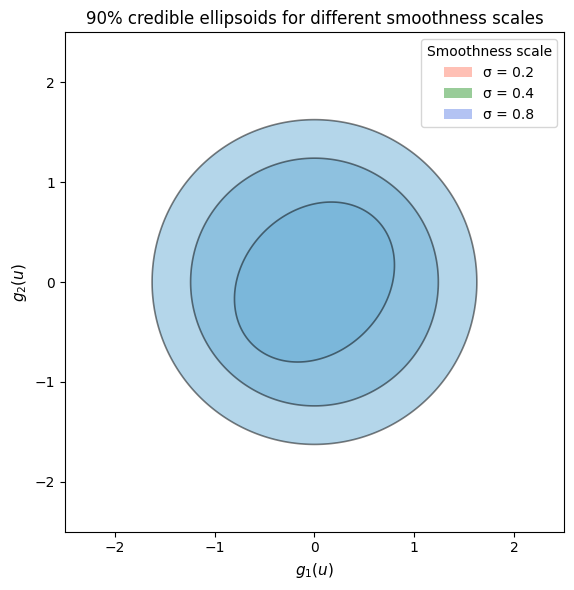

In [23]:
sigmas = [0.2, 0.4, 0.8]
colors = ["tomato", "green", "royalblue"]

fig, ax = plt.subplots(figsize=(6, 6))

for sigma_val, color in zip(sigmas, colors):
    mu_i   = L.heat_kernel_gaussian_measure(sigma_val)
    pf_i   = mu_i.affine_mapping(operator=G)           # pygeoinf push-forward

    Sigma_i     = pf_i.covariance.matrix(dense=True)
    Sigma_i_inv = np.linalg.inv(Sigma_i)

    mu_obs_i = inf.GaussianMeasure(
        covariance=inf.LinearOperator.from_matrix(data_space, data_space, Sigma_i),
        inverse_covariance=inf.LinearOperator.from_matrix(data_space, data_space, Sigma_i_inv),
    )

    cred_i = mu_obs_i.credible_set(0.90, geometry='ellipsoid')

    _, _, bdy = cred_i.plot(
        bounds=[(-2.5, 2.5), (-2.5, 2.5)],
        color=color,
        show_plot=False,
        ax=ax,
    )

legend_patches = [
    mpatches.Patch(facecolor=c, alpha=0.4, label=f"σ = {s}")
    for c, s in zip(colors, sigmas)
]
ax.legend(handles=legend_patches, fontsize=10, title="Smoothness scale")
ax.set_xlabel(r"$g_1(u)$", fontsize=11)
ax.set_ylabel(r"$g_2(u)$", fontsize=11)
ax.set_title("90% credible ellipsoids for different smoothness scales", fontsize=12)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## Summary

| Section | What we did | pygeoinf API |
|---------|-------------|--------------|
| 2 | Built $\mathcal{N}(0, e^{-\sigma^2\Delta})$ on $L^2(\mathbb{S}^2)$, $l_{\max}=12$ | `L.heat_kernel_gaussian_measure(sigma)` |
| 2.5 | Drew samples from the function-space prior | `prior.sample()` → `DHRealGrid` |
| **3** | **Created credible set $E_{0.9}^{L^2}$ in the Lebesgue space; checked membership** | **`prior.credible_set(0.90)` + `.is_element(u)`** |
| 4 | Defined two spherical cap-average functionals $g_1, g_2$ | `L.spherical_cap_average(center, radius)` |
| 5 | Assembled $G = [g_1, g_2]^\top$; pushed prior forward via `affine_mapping` | `LinearOperator.from_linear_forms(...)` + `prior.affine_mapping(operator=G)` |
| 6 | Computed exact 90% 2D credible ellipsoid $E_{0.9}^{\mathbb{R}^2}$ | `obs_measure.credible_set(0.90, geometry='ellipsoid')` |
| 7 | Drew 500 samples; checked both credible sets | `prior_cred_set.is_element(u)`, `G(u)` |
| 8 | Scatter plot coloured by function-space membership | — |
| 9 | Smoothness sweep: credible ellipsoids for $\sigma \in \{0.2,0.4,0.8\}$ | `affine_mapping` per $\sigma$ |

### Why this matters

The crucial point is that `pygeoinf` works **natively in the function space**:
- `prior.credible_set()` creates a genuine set in $L^2(\mathbb{S}^2)$, with `is_element(u)` evaluating $\langle C^{-1}u, u\rangle \le r^2$ for any `DHRealGrid` function.
- `prior.affine_mapping(operator=G)` pushes the infinite-dimensional Gaussian forward to $\mathbb{R}^2$ without ever constructing a matrix explicitly.
- The two credible sets — one in $L^2$ (169 dof) and one in $\mathbb{R}^2$ (2 dof) — are conceptually distinct but both calibrated to 90%.